<a href="https://colab.research.google.com/github/ashwiniv07/Journal-paper--DDoS-GT-DL-/blob/main/Dataset3_UNSW_UB15_with_resampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library

In [ ]:
import os
import pandas as pd
import numpy as np
import gc
from sklearn.preprocessing import LabelEncoder, StandardScaler
import shutil
from google.colab import drive
from collections import Counter
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
drive.mount('/content/drive')
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Bidirectional, GRU, Dense,
    Dropout, Flatten, Attention, Permute, Multiply, Lambda, GlobalAveragePooling1D
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, roc_curve, auc
import seaborn as sns
from tensorflow.keras.utils import to_categorical

Mounted at /content/drive


## Step 1: Dataset Collection

In [ ]:
path = '/content/drive/MyDrive/project ashwini/UNSW_NB15'
destination_folder = '/content/Dataset'
if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)
for filename in os.listdir(path):
    source_file = os.path.join(path, filename)
    destination_file = os.path.join(destination_folder, filename)
    if os.path.isfile(source_file):
        shutil.copy2(source_file, destination_file)
path = destination_folder

## Step 2: Dataset Resampling

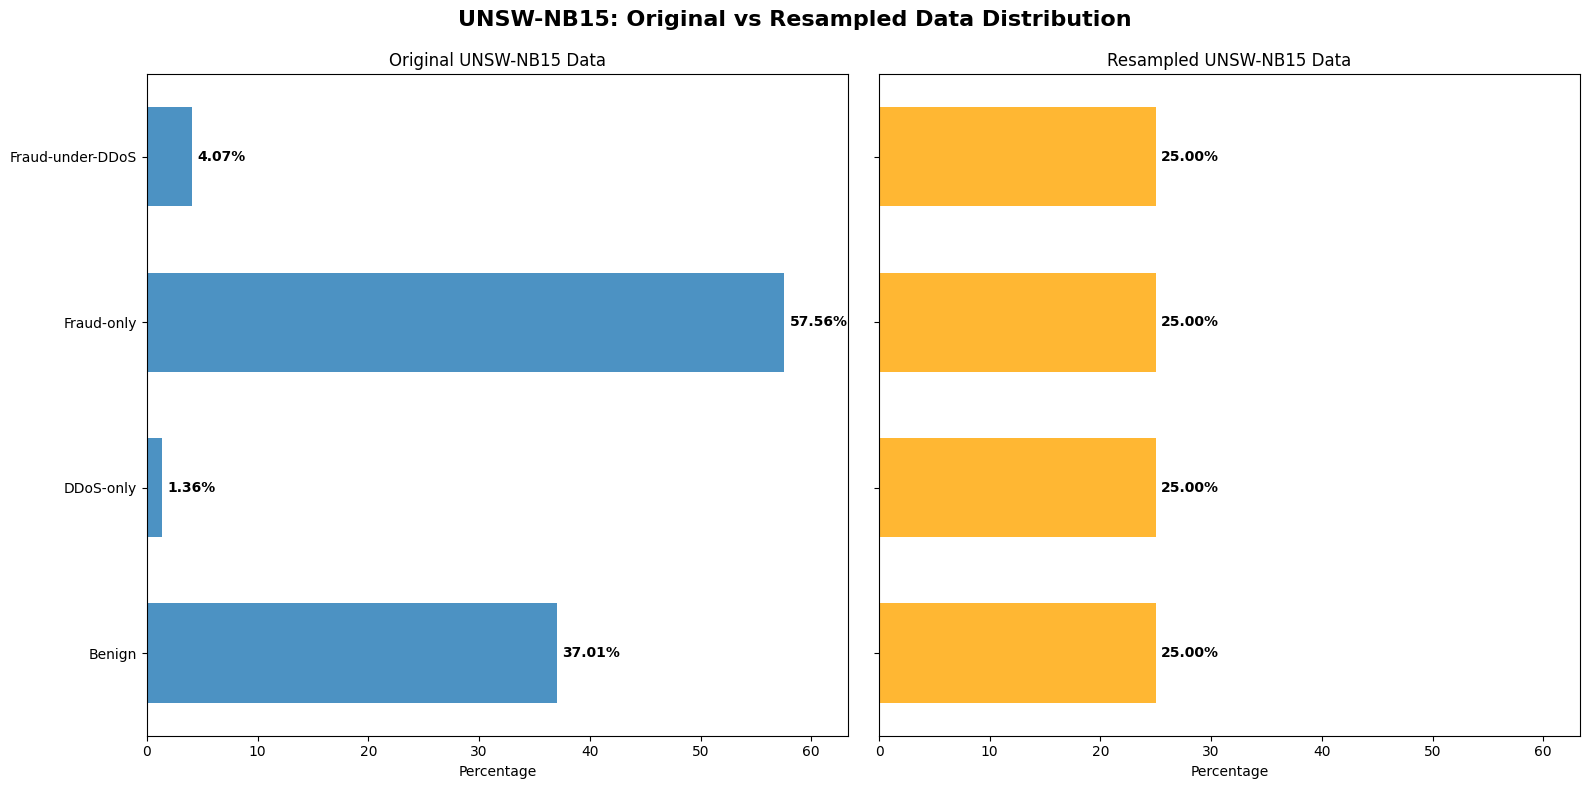

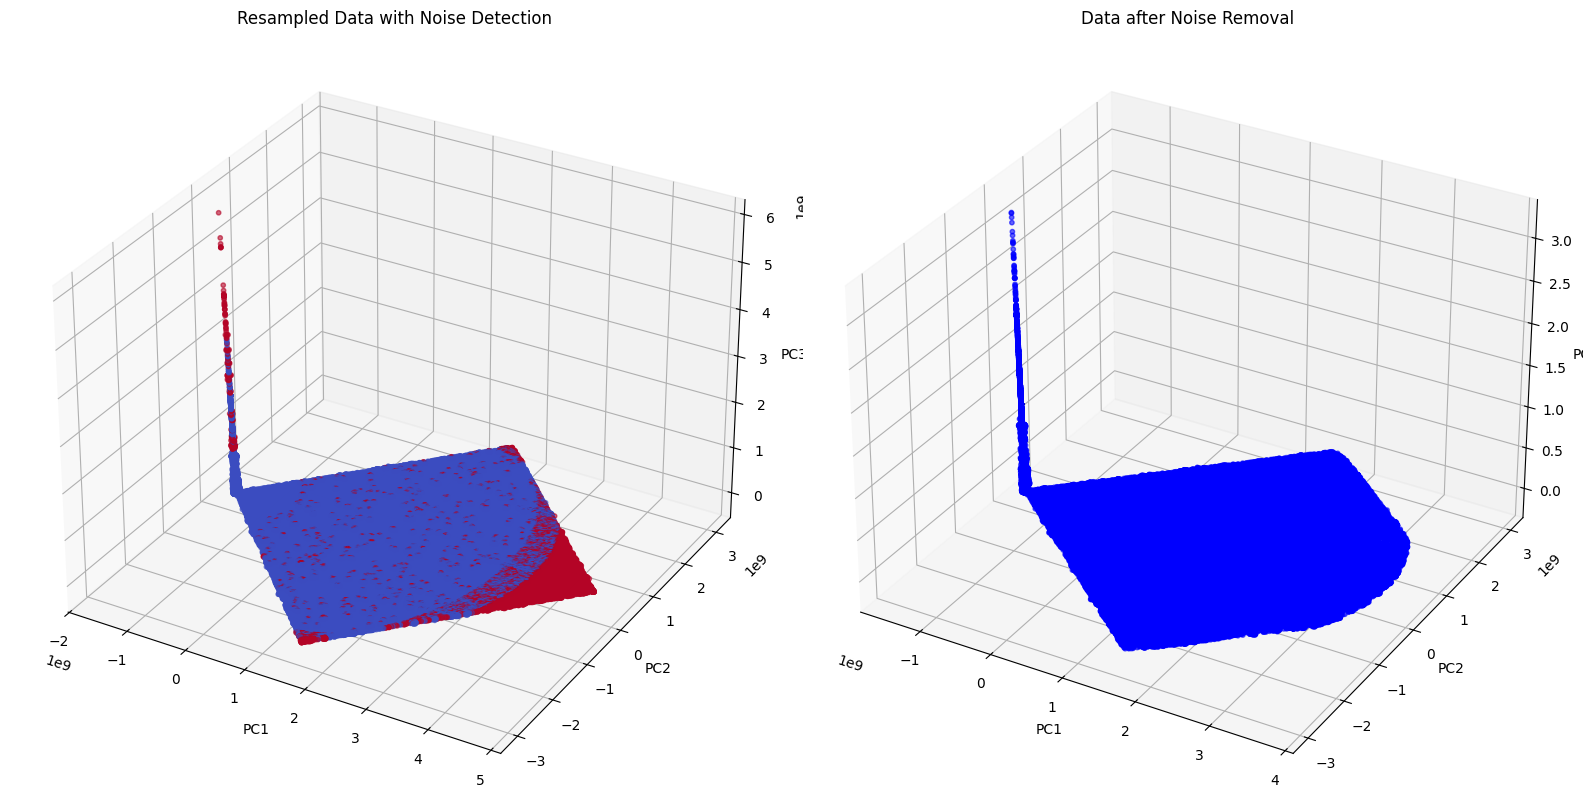

In [ ]:
class OptimizedNeuroSyncSampler:
    def __init__(self,
                 neural_depth=2,
                 evolutionary_generations=5,
                 quantum_entanglement_factor=0.7,
                 balance_strategy='adaptive',
                 target_samples_per_class=10000,
                 random_state=42):
        self.neural_depth = neural_depth
        self.evolutionary_generations = evolutionary_generations
        self.quantum_factor = quantum_entanglement_factor
        self.balance_strategy = balance_strategy
        self.target_samples = target_samples_per_class
        self.random_state = random_state
        np.random.seed(random_state)
        self.standard_scaler = StandardScaler()
        self.feature_importance_scores_ = None

    def _neural_density_estimation(self, X, y):
        unique_classes = np.unique(y)
        density_scores = {}
        for cls in unique_classes:
            X_cls = X[y == cls]
            if len(X_cls) == 0:
                continue
            if len(X_cls) > 500000:
                sample_indices = np.random.choice(len(X_cls), 10000, replace=False)
                X_cls = X_cls[sample_indices]
            density_layers = []
            for depth in range(self.neural_depth):
                bandwidth = 0.5 + (0.3 * depth / self.neural_depth)
                chunk_size = min(1000, len(X_cls))
                layer_density = np.zeros(len(X_cls))
                for i in range(0, len(X_cls), chunk_size):
                    end_idx = min(i + chunk_size, len(X_cls))
                    chunk = X_cls[i:end_idx]
                    distances = pairwise_distances(chunk, X_cls, metric='euclidean')
                    kernel_vals = np.exp(-distances**2 / (2 * bandwidth**2))
                    chunk_density = np.mean(kernel_vals, axis=1)
                    layer_density[i:end_idx] = chunk_density
                density_layers.append(layer_density)
                del distances, kernel_vals, chunk_density
                gc.collect()
            fused_density = np.mean(density_layers, axis=0)
            density_scores[cls] = fused_density
        return density_scores

    def _evolutionary_undersampling(self, X_maj, X_min, fitness_scores):
        n_target = min(self.target_samples, len(X_min))
        if len(X_maj) > 20000:
            sample_indices = np.random.choice(len(X_maj), 20000, replace=False)
            population = X_maj[sample_indices]
            fitness = fitness_scores[sample_indices]
        else:
            population = X_maj.copy()
            fitness = fitness_scores.copy()
        for generation in range(self.evolutionary_generations):
            tournament_size = min(3, len(population))
            selected_indices = []
            while len(selected_indices) < n_target:
                if len(population) == 0:
                    break
                contestants = np.random.choice(len(population), min(tournament_size, len(population)), replace=False)
                winner = contestants[np.argmax(fitness[contestants])]
                selected_indices.append(winner)
            if len(selected_indices) == 0:
                break
            population = population[selected_indices]
            fitness = fitness[selected_indices]
            if generation < self.evolutionary_generations - 1:
                mutation = np.random.normal(0, 0.05, size=population.shape)
                population = population + mutation
        return population[:n_target]

    def _quantum_noise_detection(self, X, y):
        unique_classes = np.unique(y)
        noise_mask = np.zeros(len(X), dtype=bool)
        for cls in unique_classes:
            X_cls = X[y == cls]
            if len(X_cls) < 10:
                continue
            centroid = np.mean(X_cls, axis=0)
            distances = np.linalg.norm(X_cls - centroid, axis=1)
            threshold = np.percentile(distances, 95)
            class_indices = np.where(y == cls)[0]
            class_noise_mask = distances > threshold
            noise_mask[class_indices] = class_noise_mask
            del distances
            gc.collect()
        return noise_mask

    def _calculate_feature_importance(self, X, y):
        unique_classes = np.unique(y)
        importance_scores = np.zeros(X.shape[1])
        if len(X) > 10000:
            sample_indices = np.random.choice(len(X), 10000, replace=False)
            X_sample = X[sample_indices]
            y_sample = y[sample_indices]
        else:
            X_sample = X
            y_sample = y
        for feature_idx in range(X_sample.shape[1]):
            feature_vals = X_sample[:, feature_idx]
            class_means = []
            for cls in unique_classes:
                class_vals = feature_vals[y_sample == cls]
                if len(class_vals) > 0:
                    class_means.append(np.mean(class_vals))
            if len(class_means) > 1:
                between_class_var = np.var(class_means)
            else:
                between_class_var = 0
            if between_class_var > 0:
                importance_scores[feature_idx] = between_class_var
            else:
                importance_scores[feature_idx] = 0
        if np.sum(importance_scores) > 0:
            importance_scores = importance_scores / np.sum(importance_scores)
        self.feature_importance_scores_ = importance_scores
        return importance_scores

    def fit_resample(self, X, y):
        X = np.array(X)
        y = np.array(y)
        gc.collect()
        feature_importance = self._calculate_feature_importance(X, y)
        X_weighted = X * feature_importance
        X_scaled = self.standard_scaler.fit_transform(X_weighted)
        class_counts = Counter(y)
        target_size = self.target_samples
        unique_classes = np.unique(y)
        X_resampled_list = []
        y_resampled_list = []
        for cls in unique_classes:
            X_cls = X_scaled[y == cls]
            y_cls = y[y == cls]
            n_current = len(X_cls)
            if n_current == 0:
                continue
            if n_current < target_size:
                n_needed = target_size - n_current
                if n_needed > 0:
                    oversample_indices = np.random.choice(n_current, n_needed, replace=True)
                    synthetic_samples = X_cls[oversample_indices] + np.random.normal(0, 0.01, X_cls[oversample_indices].shape)
                    X_oversampled = np.vstack([X_cls, synthetic_samples])
                    y_oversampled = np.concatenate([y_cls, [cls] * n_needed])
                else:
                    X_oversampled = X_cls
                    y_oversampled = y_cls
                X_resampled_list.append(X_oversampled)
                y_resampled_list.append(y_oversampled)
            elif n_current > target_size:
                selected_indices = np.random.choice(n_current, target_size, replace=False)
                X_resampled_list.append(X_cls[selected_indices])
                y_resampled_list.append(np.array([cls] * target_size))
            else:
                X_resampled_list.append(X_cls)
                y_resampled_list.append(y_cls)
            del X_cls, y_cls
            gc.collect()
        X_balanced = np.vstack(X_resampled_list)
        y_balanced = np.concatenate(y_resampled_list)
        X_final = self.standard_scaler.inverse_transform(X_balanced)
        X_final = X_final / feature_importance
        del X_balanced, X_scaled, X_weighted
        gc.collect()
        return X_final, y_balanced
def calculate_unsw_fraud_score(df):
    quantiles = {}
    numeric_features = ['sbytes', 'dbytes', 'sttl', 'dttl', 'sload', 'dload',
                       'spkts', 'dpkts', 'swin', 'dwin', 'dur']

    for feature in numeric_features:
        if feature in df.columns:
            try:
                quantiles[feature] = {
                    'q10': df[feature].quantile(0.10),
                    'q90': df[feature].quantile(0.90)
                }
            except:
                pass

    def fraud_score(row):
        score = 0

        try:
            if 'sbytes' in quantiles and pd.notna(row.get('sbytes')):
                if (row['sbytes'] < quantiles['sbytes']['q10'] or
                    row['sbytes'] > quantiles['sbytes']['q90']):
                    score += 1
            if 'sttl' in quantiles and pd.notna(row.get('sttl')):
                if row['sttl'] < quantiles['sttl']['q10']:
                    score += 1
            if 'sload' in quantiles and pd.notna(row.get('sload')):
                if row['sload'] > quantiles['sload']['q90']:
                    score += 1
            if 'spkts' in quantiles and pd.notna(row.get('spkts')):
                if (row['spkts'] < quantiles['spkts']['q10'] or
                    row['spkts'] > quantiles['spkts']['q90']):
                    score += 1
            if 'state' in df.columns and pd.notna(row.get('state')):
                suspicious_states = ['RST', 'FIN', 'CON', 'INT']
                if row['state'] in suspicious_states:
                    score += 1
            if 'service' in df.columns and pd.notna(row.get('service')):
                suspicious_services = ['-', 'http', 'dns', 'smtp']
                if row['service'] in suspicious_services:
                    score += 1
            if 'dur' in df.columns and pd.notna(row.get('dur')):
                if row['dur'] > 3600 or row['dur'] < 0.001:
                    score += 1
        except Exception as e:
            pass

        return score

    df['fraud_score'] = df.apply(fraud_score, axis=1)
    return df

def relabel_unsw_nb15(df, fraud_threshold=3):
    BENIGN = ['Normal']
    DDoS_ATTACKS = ['DoS', 'Dos']
    FRAUD_ATTACKS = [
        'Backdoor', 'Analysis', 'Fuzzers', 'Shellcode',
        'Reconnaissance', 'Exploits', 'Worms', 'Generic'
    ]
    if 'attack_cat' in df.columns:
        df['Label'] = df['attack_cat'].astype(str).str.strip().str.title()
    elif 'Label' in df.columns:
        df['Label'] = df['Label'].astype(str).str.strip().str.title()
    else:
        return df
    df['is_ddos'] = df['Label'].apply(
        lambda x: 1 if any(ddos in x for ddos in DDoS_ATTACKS) else 0
    )
    df['is_fraud'] = df['Label'].apply(
        lambda x: 1 if any(fraud in x for fraud in FRAUD_ATTACKS) else 0
    )
    df['is_benign'] = df['Label'].apply(
        lambda x: 1 if any(benign in x for benign in BENIGN) else 0
    )
    if 'stime' in df.columns:
        df['timestamp'] = pd.to_datetime(df['stime'], errors='coerce')
    else:
        df['timestamp'] = pd.date_range(start='2023-01-01', periods=len(df), freq='S')
    if df['timestamp'].isna().any():
        df.loc[df['timestamp'].isna(), 'timestamp'] = pd.date_range(
            start='2023-01-02', periods=df['timestamp'].isna().sum(), freq='S'
        )
    df['window'] = df['timestamp'].dt.floor('5min')
    ddos_windows = df[df['is_ddos'] == 1].groupby('window').size()
    if len(ddos_windows) > 0:
        threshold = max(5, ddos_windows.quantile(0.5))
        active_ddos_windows = set(ddos_windows[ddos_windows >= threshold].index)
    else:
        active_ddos_windows = set()
    df = calculate_unsw_fraud_score(df)
    def categorize_attack(row):
        label = row['Label']
        fraud_score = row['fraud_score']
        window = row['window']
        if any(benign in label for benign in BENIGN):
            return 'Benign'
        if fraud_score >= fraud_threshold:
            if row['is_ddos'] == 1 and window in active_ddos_windows:
                return 'Fraud-under-DDoS'
            elif row['is_fraud'] == 1:
                return 'Fraud-only'
            else:
                return 'Benign'
        else:
            if row['is_ddos'] == 1:
                return 'DDoS-only'
            elif row['is_fraud'] == 1:
                return 'Fraud-only'
            else:
                return 'Benign'
    df['Final_Label'] = df.apply(categorize_attack, axis=1)
    return df
def main():
    path = 'Dataset'
    all_files = [os.path.join(dirname, filename) for dirname, _, filenames in os.walk(path)
                 for filename in filenames if filename.endswith('.csv')]
    processed_dfs = []
    sample_fraction = 0.1
    for i, file_path in enumerate(all_files):
        try:
            df = pd.read_csv(file_path)
            if len(df) > 500000:
                df = df.sample(frac=sample_fraction, random_state=42)
            df = relabel_unsw_nb15(df)
            processed_dfs.append(df)
            del df
            gc.collect()
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
            gc.collect()
    if processed_dfs:
        combined_df = pd.concat(processed_dfs, ignore_index=True)
        del processed_dfs
        gc.collect()
        essential_features = [
            'sbytes', 'dbytes', 'sttl', 'dttl', 'sload', 'dload', 'spkts', 'dpkts',
            'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth',
            'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt', 'dintpkt',
            'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl',
            'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src',
            'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm',
            'ct_dst_sport_ltm', 'ct_dst_src_ltm'
        ]
        available_features = [f for f in essential_features if f in combined_df.columns]
        available_features = available_features[:20]
        sampling_df = combined_df[available_features + ['Final_Label']].dropna()
        if len(sampling_df) > 500000:
            sampling_df = sampling_df.sample(n=500000, random_state=42)
        X = sampling_df[available_features].values
        y = sampling_df['Final_Label'].values
        sampler = OptimizedNeuroSyncSampler(
            neural_depth=2,
            evolutionary_generations=3,
            target_samples_per_class=90000,
            random_state=42
        )
        X_resampled, y_resampled = sampler.fit_resample(X, y)
        del X, y, sampling_df
        gc.collect()
        balanced_df = pd.DataFrame(X_resampled, columns=available_features)
        balanced_df['Label'] = y_resampled
        balanced_csv_path = "UNSW_NB15_Balanced.csv"
        balanced_df.to_csv(balanced_csv_path, index=False)
        del X_resampled, y_resampled
        gc.collect()
        original_counts = combined_df['Final_Label'].value_counts()
        resampled_counts = balanced_df['Label'].value_counts()
        original_percentages = (original_counts / original_counts.sum()) * 100
        resampled_percentages = (resampled_counts / resampled_counts.sum()) * 100
        all_classes = sorted(set(original_counts.index) | set(resampled_counts.index))
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        y_pos = np.arange(len(all_classes))
        original_values = [original_percentages.get(cls, 0) for cls in all_classes]
        bars1 = ax1.barh(y_pos, original_values, align='center', alpha=0.8, height=0.6)
        ax1.set_yticks(y_pos)
        ax1.set_yticklabels(all_classes)
        ax1.set_xlabel('Percentage')
        ax1.set_title('Original UNSW-NB15 Data')
        ax1.invert_yaxis()
        for i, v in enumerate(original_values):
            ax1.text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold')
        resampled_values = [resampled_percentages.get(cls, 0) for cls in all_classes]
        bars2 = ax2.barh(y_pos, resampled_values, align='center', alpha=0.8, color='orange', height=0.6)
        ax2.set_yticks(y_pos)
        ax2.set_yticklabels([])
        ax2.set_xlabel('Percentage')
        ax2.set_title('Resampled UNSW-NB15 Data')
        ax2.invert_yaxis()
        for i, v in enumerate(resampled_values):
            ax2.text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold')
        max_x = max(max(original_values), max(resampled_values)) * 1.1
        ax1.set_xlim(0, max_x)
        ax2.set_xlim(0, max_x)
        ax1.set_ylim(-0.5, len(all_classes) - 0.5)
        ax2.set_ylim(-0.5, len(all_classes) - 0.5)
        plt.suptitle('UNSW-NB15: Original vs Resampled Data Distribution', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.subplots_adjust(top=0.9)
        plt.show()
        sampler_viz = OptimizedNeuroSyncSampler()
        noise_mask_centroid = sampler_viz._quantum_noise_detection(balanced_df[available_features].values,
                                                                 balanced_df['Label'].values)
        pca = PCA(n_components=3)
        X_pca = pca.fit_transform(balanced_df[available_features])
        fig = plt.figure(figsize=(16, 8))
        ax1 = fig.add_subplot(121, projection='3d')
        scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                              c=noise_mask_centroid, cmap='coolwarm', alpha=0.6, s=10)
        ax1.set_title('Resampled Data with Noise Detection')
        ax1.set_xlabel('PC1')
        ax1.set_ylabel('PC2')
        ax1.set_zlabel('PC3')
        X_clean_centroid = X_pca[~noise_mask_centroid]
        ax2 = fig.add_subplot(122, projection='3d')
        scatter2 = ax2.scatter(X_clean_centroid[:, 0], X_clean_centroid[:, 1], X_clean_centroid[:, 2],
                              c='blue', alpha=0.6, s=10)
        ax2.set_title('Data after Noise Removal')
        ax2.set_xlabel('PC1')
        ax2.set_ylabel('PC2')
        ax2.set_zlabel('PC3')
        plt.tight_layout()
        plt.show()
        fraud_under_ddos = len(balanced_df[balanced_df['Label'] == 'Fraud-under-DDoS'])
        total_attacks = len(balanced_df[balanced_df['Label'] != 'Benign'])
        if total_attacks > 0:
            fraud_under_ddos_pct = (fraud_under_ddos / total_attacks) * 100

    else:
        print("\nNo dataframes collected. Processing failed.")

if __name__ == "__main__":
    main()

## Step 3: Apply Preprocessing such as

### 1	Drop irrelevant columns	Reason: Remove non-useful or redundant information
### 2	Drop constant columns	Reason: Eliminate features with no variability
### 3	Encode labels	Reason: Convert categorical target to numeric
### 4	Handle missing values	Ensure no NaN values
### 5	Normalize features	Standardize numeric input features
### 6	Feature-label split	Prepare for training/evaluation

In [ ]:
def prepare_unsw_data(file_path='UNSW_NB15_Balanced.csv'):
    df = pd.read_csv(file_path)
    label_column = None
    possible_label_cols = ['Label', 'Final_Label', 'label', 'attack_cat', 'category']
    for col in possible_label_cols:
        if col in df.columns:
            label_column = col
            break
    if label_column is None:
        label_column = df.columns[-1]
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    constant_cols = df.columns[df.nunique() <= 1]
    if len(constant_cols) > 0:
        df.drop(columns=constant_cols, inplace=True)
    le = LabelEncoder()
    df['Label_encoded'] = le.fit_transform(df[label_column])
    label_map = dict(zip(le.classes_, le.transform(le.classes_)))
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    if 'Label_encoded' in numeric_cols:
        numeric_cols.remove('Label_encoded')
    index_like_cols = [col for col in numeric_cols if 'index' in col.lower() or 'id' in col.lower()]
    if index_like_cols:
        numeric_cols = [col for col in numeric_cols if col not in index_like_cols]
    scaler = StandardScaler()
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    X = df[numeric_cols].values
    y = to_categorical(df['Label_encoded'].values)
    X_reshaped = X.reshape((X.shape[0], 1, X.shape[1]))
    unique, counts = np.unique(df['Label_encoded'], return_counts=True)
    for cls_idx, count in zip(unique, counts):
        cls_name = le.inverse_transform([cls_idx])[0]
        percentage = (count / len(df)) * 100

    return X_reshaped, y, le, scaler, numeric_cols, df
if __name__ == "__main__":
    try:
        X, y, le, feature_scaler, feature_names, original_df = prepare_unsw_data()
    except FileNotFoundError:
      pass
    except Exception as e:
        print(f"Error during data preparation: {e}")

## Step 4: Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 5: Build Proposed CNN-BiGRU Model

In [ ]:
def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(filters=64, kernel_size=1, activation='relu')(inputs)
    x = MaxPooling1D(pool_size=1)(x)
    x = Bidirectional(GRU(64, return_sequences=True))(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## Step 6: Train Proposed Model

In [ ]:
model = build_model(input_shape=X_train.shape[1:], num_classes=y_train.shape[1])
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150,
    batch_size=32,
    verbose=1
)

Epoch 1/150
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 61s 6ms/step - accuracy: 0.7108 - loss: 0.6915 - val_accuracy: 0.7475 - val_loss: 0.5970
Epoch 2/150
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 59s 7ms/step - accuracy: 0.7445 - loss: 0.6047 - val_accuracy: 0.7549 - val_loss: 0.5804
Epoch 3/150
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - accuracy: 0.7503 - loss: 0.5874 - val_accuracy: 0.7582 - val_loss: 0.5706
Epoch 4/150
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 81s 6ms/step - accuracy: 0.7572 - loss: 0.5692 - val_accuracy: 0.7805 - val_loss: 0.5004
Epoch 5/150
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 57s 6ms/step - accuracy: 0.7684 - loss: 0.5273 - val_accuracy: 0.7651 - val_loss: 0.5460
Epoch 6/150
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 56s 6ms/step - accuracy: 0.7719 - loss: 0.5129 - val_accuracy: 0.7626 - val_loss: 0.5190
Epoch 7/150
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 53s 6ms/step - accuracy: 0.7776 - loss: 0.4948 - val_accuracy: 0.7992 - val_loss: 0.4545
Epoch 8/150
9000/9000 ━━━━━━━━━━━━━━━━━━━━ 55s 6ms/step - accuracy: 0.7850 -

## Step 7: Evaluate Proposed Model

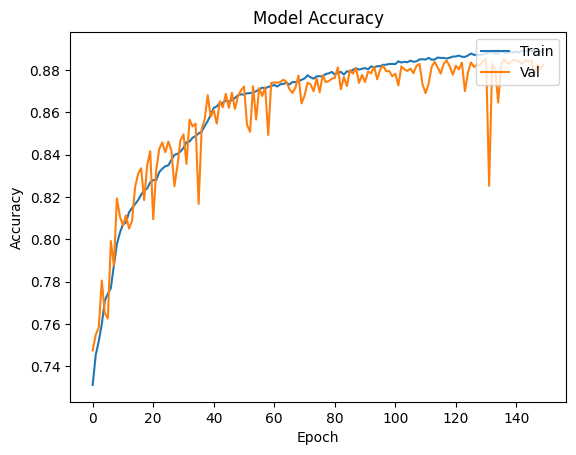

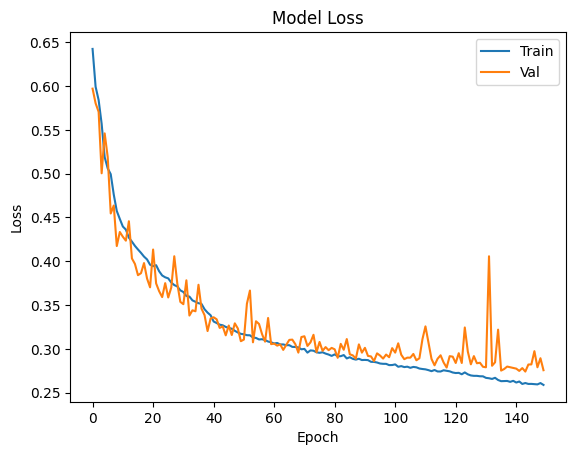

2250/2250 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step

 Classification Report:
                  precision    recall  f1-score   support

          Benign       0.89      0.87      0.88     18071
       DDoS-only       0.92      0.97      0.94     18108
      Fraud-only       0.76      0.83      0.80     17886
Fraud-under-DDoS       0.98      0.86      0.92     17935

        accuracy                           0.88     72000
       macro avg       0.89      0.88      0.88     72000
    weighted avg       0.89      0.88      0.88     72000



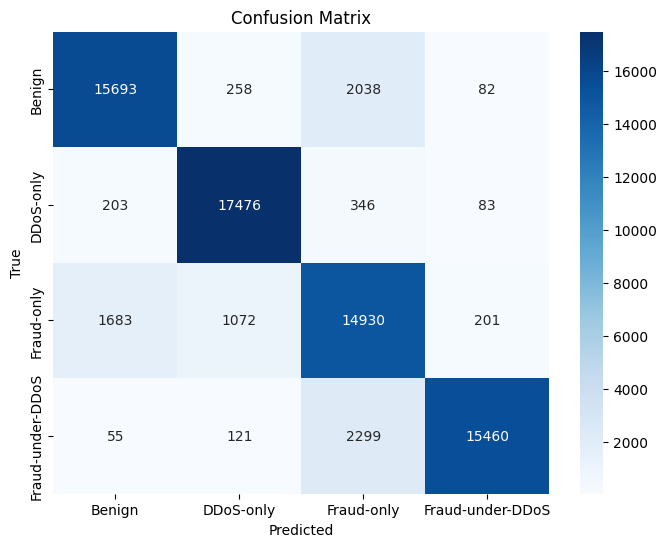

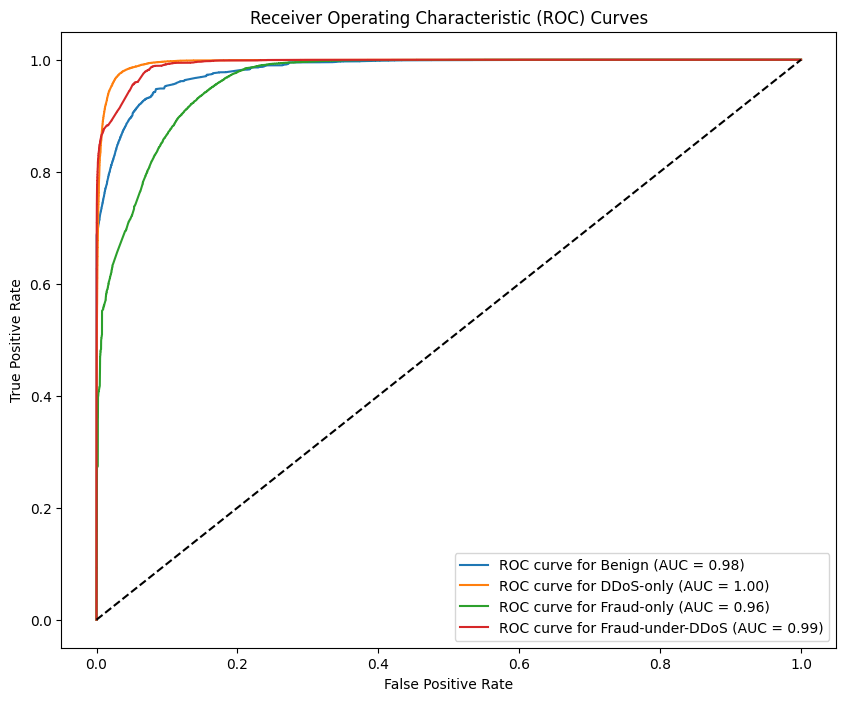


 AUC Score (OvR): 0.9836


In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()
target_names = [str(c) for c in le.classes_]

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)


print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

plt.figure(figsize=(10, 8))
for i in range(len(target_names)):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f'ROC curve for {target_names[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.show()

try:
    auc_score = roc_auc_score(y_test, y_pred_probs, multi_class="ovr")
    print(f"\n AUC Score (OvR): {auc_score:.4f}")
except Exception as e:
    print(" Could not compute AUC:", e)


# Step 8: Implementation of Proposed CADE-GF

## Step 8 (a): Attacker Utility Function

In [ ]:
def attacker_utility(prob_fraud, threshold=0.5, cost_detected=1.0, reward_evade=5.0, cost_false_positive=0.5):
    if prob_fraud >= threshold:
        return -cost_detected * prob_fraud
    else:
        return reward_evade * (1 - prob_fraud) - cost_false_positive * prob_fraud

## Step 8 (b): Threshold Search Resolution Function

In [ ]:
def optimal_threshold(pred_probs, true_labels):
    thresholds = np.linspace(0.1, 0.9, 81)
    best_thresh = 0.5
    min_utility = float('inf')

    for t in thresholds:
        evasion_utilities = [
            attacker_utility(prob, threshold=t, cost_detected=2.0)
            for prob, true in zip(pred_probs, true_labels) if true != 0
        ]
        if evasion_utilities:
            avg_utility = np.mean(evasion_utilities)
            if avg_utility < min_utility:
                min_utility = avg_utility
                best_thresh = t
    return best_thresh

## Step 8 (c): Evasion Attack function

In [ ]:
def simulate_evasion(X, numeric_cols_indices, epsilon=0.1):
    X_evaded = X.copy()
    X_reshaped = X_evaded.reshape(X_evaded.shape[0], X_evaded.shape[2])
    noise = np.random.normal(0, epsilon, size=(X_reshaped.shape[0], len(numeric_cols_indices)))
    X_reshaped[:, numeric_cols_indices] += noise
    X_evaded = X_reshaped.reshape(X_evaded.shape)
    return X_evaded

## Step 9: Evalaution of CADE-GF
### Print Evalaution Metrics (AUC) Before/After

In [ ]:
feature_names = feature_names
continuous_traffic_features = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean',
    'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std',
    'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Bwd IAT Total',
    'Bwd IAT Mean', 'Bwd IAT Std', 'Fwd Header Length', 'Bwd Header Length',
    'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
    'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    'Down/Up Ratio', 'Average Packet Size', 'Avg Fwd Segment Size',
    'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Fwd Avg Bytes/Bulk',
    'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
    'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Subflow Fwd Packets',
    'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes',
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd',
    'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max',
    'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min'
]
continuous_features_to_perturb = [f for f in continuous_traffic_features if f in feature_names]
continuous_feature_indices = [feature_names.index(f) for f in continuous_features_to_perturb if f in feature_names]
pred_probs = model.predict(X_test)
fraud_probs = pred_probs[:, 1]
y_true = np.argmax(y_test, axis=1)
opt_thresh = optimal_threshold(fraud_probs, y_true)
print(f"Optimal threshold: {opt_thresh:.3f}")
y_clean = (fraud_probs >= opt_thresh).astype(int)
X_evaded = simulate_evasion(X_test, continuous_feature_indices, epsilon=0.1)
fraud_probs_evaded = model.predict(X_evaded)[:, 1]
y_evaded = (fraud_probs_evaded >= opt_thresh).astype(int)
try:
    auc_clean = roc_auc_score(y_test, model.predict(X_test), multi_class='ovr')
    auc_evade = roc_auc_score(y_test, model.predict(X_evaded), multi_class='ovr')
    print(f"AUC (clean): {auc_clean:.4f}")
    print(f"AUC (evaded): {auc_evade:.4f}")
    print(f"AUC degradation: {auc_clean - auc_evade:.4f}")
    evasion_success = np.mean((y_clean == 1) & (y_evaded == 0))
    print(f"Evasion success rate: {evasion_success:.4f}")
except Exception as e:
    print(f"Evaluation error: {e}")

2250/2250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
Optimal threshold: 0.100
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
AUC (clean): 0.9836
AUC (evaded): 0.9836
AUC degradation: 0.0000
Evasion success rate: 0.0000
